In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams["figure.figsize"] = (10,5)

In [3]:
DATASET = Path(
    r"C:\Users\Ashal.Meeqaat\Desktop\Medical_KG_Project\datasets"
)
HETIONET = DATASET / "hetionet-main" / "hetnet" / "tsv" / "edges.sif"

In [4]:
hetionet = pd.read_csv(
    HETIONET,
    sep="\t"
)

hetionet.head()

,source,metaedge,target
0,Gene::9021,GpBP,Biological Process::GO:0071357
1,Gene::51676,GpBP,Biological Process::GO:0098780
2,Gene::19,GpBP,Biological Process::GO:0055088
3,Gene::3176,GpBP,Biological Process::GO:0010243
4,Gene::3039,GpBP,Biological Process::GO:0006898


In [5]:
print("="*60)
print("HETIONET DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {hetionet.shape[0]:,}")
print(f"Columns : {hetionet.shape[1]}")

print("\nMemory Usage")
print(
    round(
        hetionet.memory_usage(deep=True).sum()/1024**2,
        2
    ),
    "MB"
)

HETIONET DATASET OVERVIEW
Rows    : 2,250,197
Columns : 3

Memory Usage
129.92 MB


In [6]:
hetionet.info()

<class 'pandas.DataFrame'>
RangeIndex: 2250197 entries, 0 to 2250196
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   source    str  
 1   metaedge  str  
 2   target    str  
dtypes: str(3)
memory usage: 129.9 MB


In [7]:
hetionet.columns.tolist()

['source', 'metaedge', 'target']

In [8]:
display(hetionet.head())

display(hetionet.tail())

display(hetionet.sample(5))

,source,metaedge,target
0,Gene::9021,GpBP,Biological Process::GO:0071357
1,Gene::51676,GpBP,Biological Process::GO:0098780
2,Gene::19,GpBP,Biological Process::GO:0055088
3,Gene::3176,GpBP,Biological Process::GO:0010243
4,Gene::3039,GpBP,Biological Process::GO:0006898


,source,metaedge,target
2250192,Anatomy::UBERON:0000057,AeG,Gene::65009
2250193,Anatomy::UBERON:0000474,AeG,Gene::80279
2250194,Anatomy::UBERON:0002048,AeG,Gene::1211
2250195,Anatomy::UBERON:0002048,AeG,Gene::8843
2250196,Anatomy::UBERON:0002240,AeG,Gene::2124


,source,metaedge,target
1589769,Compound::DB00877,CcSE,Side Effect::C0001122
171510,Gene::123745,GpBP,Biological Process::GO:0006650
682508,Gene::124,GiG,Gene::1459
2124876,Anatomy::UBERON:0002048,AeG,Gene::60312
871649,Anatomy::UBERON:0001675,AdG,Gene::5018


In [9]:
missing = hetionet.isna().sum()

missing

source      0
metaedge    0
target      0
dtype: int64

In [10]:
duplicates = hetionet.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [11]:
metaedge_counts = hetionet["metaedge"].value_counts()

metaedge_counts

metaedge
GpBP    559504
AeG     526407
Gr>G    265672
GiG     147164
CcSE    138944
AdG     102240
AuG      97848
GpMF     97222
GpPW     84372
GpCC     73566
GcG      61690
CdG      21102
CuG      18756
DaG      12623
CbG      11571
DuG       7731
DdG       7623
CrC       6486
DlA       3602
DpS       3357
PCiC      1029
CtD        755
DrD        543
CpD        390
Name: count, dtype: int64

In [12]:
metaedge_counts.head(20)

metaedge
GpBP    559504
AeG     526407
Gr>G    265672
GiG     147164
CcSE    138944
AdG     102240
AuG      97848
GpMF     97222
GpPW     84372
GpCC     73566
GcG      61690
CdG      21102
CuG      18756
DaG      12623
CbG      11571
DuG       7731
DdG       7623
CrC       6486
DlA       3602
DpS       3357
Name: count, dtype: int64

In [13]:
source_nodes = set(hetionet["source"])

target_nodes = set(hetionet["target"])

all_nodes = source_nodes.union(target_nodes)

print("Unique Source Nodes :", len(source_nodes))

print("Unique Target Nodes :", len(target_nodes))

print("Total Unique Nodes  :", len(all_nodes))

Unique Source Nodes : 20138
Unique Target Nodes : 44204
Total Unique Nodes  : 45158


In [14]:
hetionet["source_type"] = hetionet["source"].str.split("::").str[0]

hetionet["target_type"] = hetionet["target"].str.split("::").str[0]

In [15]:
print("Source Types")

display(
    hetionet["source_type"].value_counts()
)

print()

print("Target Types")

display(
    hetionet["target_type"].value_counts()
)

Source Types


source_type
Gene                   1289190
Anatomy                 726495
Compound                198004
Disease                  35479
Pharmacologic Class       1029
Name: count, dtype: int64


Target Types


target_type
Gene                  1280427
Biological Process     559504
Side Effect            138944
Molecular Function      97222
Pathway                 84372
Cellular Component      73566
Compound                 7515
Anatomy                  3602
Symptom                  3357
Disease                  1688
Name: count, dtype: int64

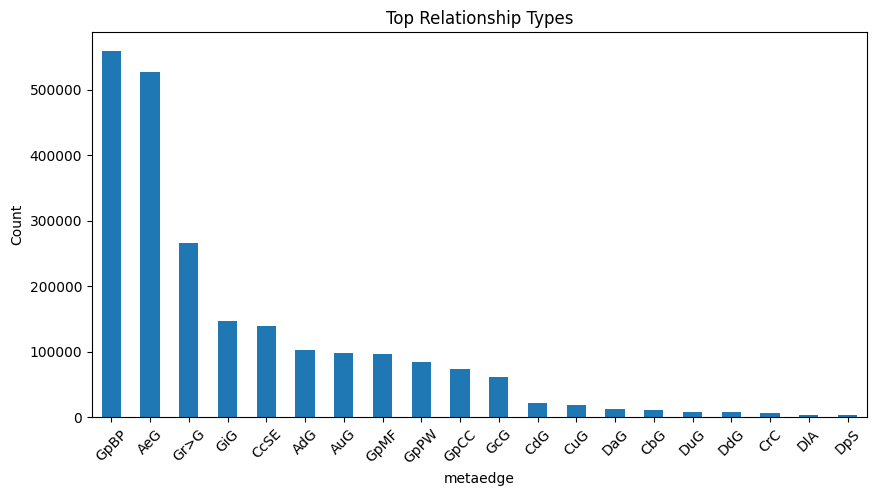

In [16]:
metaedge_counts.head(20).plot(
    kind="bar"
)

plt.title("Top Relationship Types")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

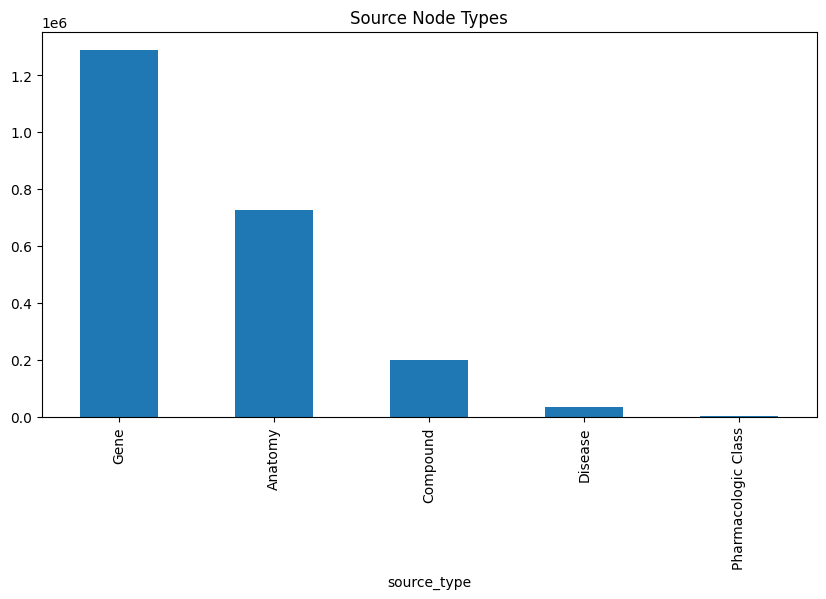

In [17]:
hetionet["source_type"].value_counts().plot(
    kind="bar"
)

plt.title("Source Node Types")

plt.show()

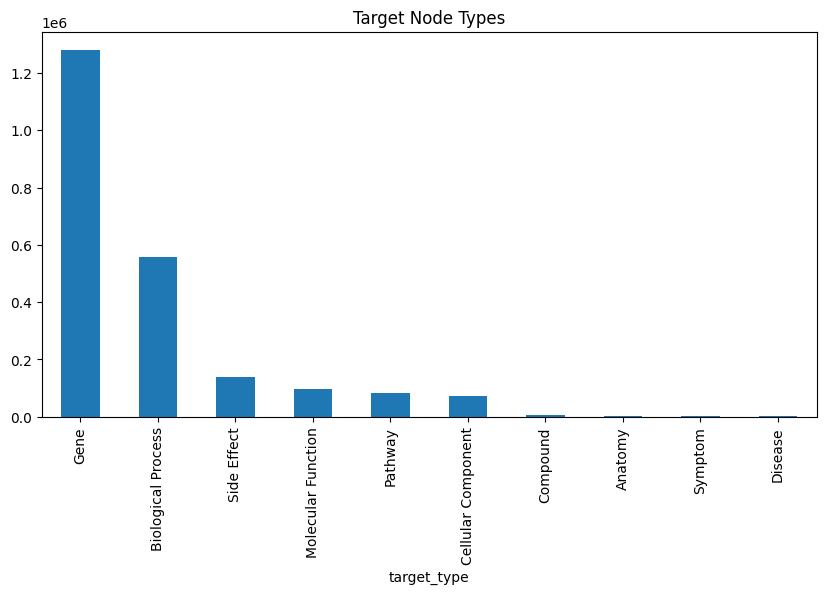

In [18]:
hetionet["target_type"].value_counts().plot(
    kind="bar"
)

plt.title("Target Node Types")

plt.show()

In [19]:
print("="*50)

print("Graph Statistics")

print("="*50)

print("Edges :", len(hetionet))

print("Nodes :", len(all_nodes))

print("Relation Types :", hetionet["metaedge"].nunique())

print("Source Types :", hetionet["source_type"].nunique())

print("Target Types :", hetionet["target_type"].nunique())

Graph Statistics
Edges : 2250197
Nodes : 45158
Relation Types : 24
Source Types : 5
Target Types : 10


✔ Graph Dataset

✔ Already edge list

✔ Multiple node categories

✔ Easy Neo4j import

✔ Rich relationship types

Overall Rating

⭐⭐⭐⭐⭐

| Card                      | Query        |
| ------------------------- | ------------ |
| Total Nodes               | count(nodes) |
| Total Edges               | count(edges) |
| Relationship Distribution | Bar Chart    |
| Node Types                | Pie Chart    |
| Top Connected Nodes       | Table        |
| Graph Viewer              | Graph        |


In [20]:
print("="*60)
print("GRAPH STATISTICS")
print("="*60)

# Total edges
print(f"Total Edges : {len(hetionet):,}")

# Unique nodes
source_nodes = set(hetionet["source"])
target_nodes = set(hetionet["target"])
all_nodes = source_nodes.union(target_nodes)

print(f"Unique Nodes : {len(all_nodes):,}")

# Relationship types
print(f"Metaedge Types : {hetionet['metaedge'].nunique()}")

print(f"Source Node Types : {hetionet['source_type'].nunique()}")

print(f"Target Node Types : {hetionet['target_type'].nunique()}")

GRAPH STATISTICS
Total Edges : 2,250,197
Unique Nodes : 45,158
Metaedge Types : 24
Source Node Types : 5
Target Node Types : 10


In [21]:
source_counts = hetionet["source_type"].value_counts()

display(source_counts)

source_type
Gene                   1289190
Anatomy                 726495
Compound                198004
Disease                  35479
Pharmacologic Class       1029
Name: count, dtype: int64

In [22]:
target_counts = hetionet["target_type"].value_counts()

display(target_counts)

target_type
Gene                  1280427
Biological Process     559504
Side Effect            138944
Molecular Function      97222
Pathway                 84372
Cellular Component      73566
Compound                 7515
Anatomy                  3602
Symptom                  3357
Disease                  1688
Name: count, dtype: int64

In [23]:
all_types = pd.concat([
    hetionet["source_type"],
    hetionet["target_type"]
])

node_counts = all_types.value_counts()

display(node_counts)

Gene                   2569617
Anatomy                 730097
Biological Process      559504
Compound                205519
Side Effect             138944
Molecular Function       97222
Pathway                  84372
Cellular Component       73566
Disease                  37167
Symptom                   3357
Pharmacologic Class       1029
Name: count, dtype: int64

In [24]:
display(metaedge_counts)

metaedge
GpBP    559504
AeG     526407
Gr>G    265672
GiG     147164
CcSE    138944
AdG     102240
AuG      97848
GpMF     97222
GpPW     84372
GpCC     73566
GcG      61690
CdG      21102
CuG      18756
DaG      12623
CbG      11571
DuG       7731
DdG       7623
CrC       6486
DlA       3602
DpS       3357
PCiC      1029
CtD        755
DrD        543
CpD        390
Name: count, dtype: int64

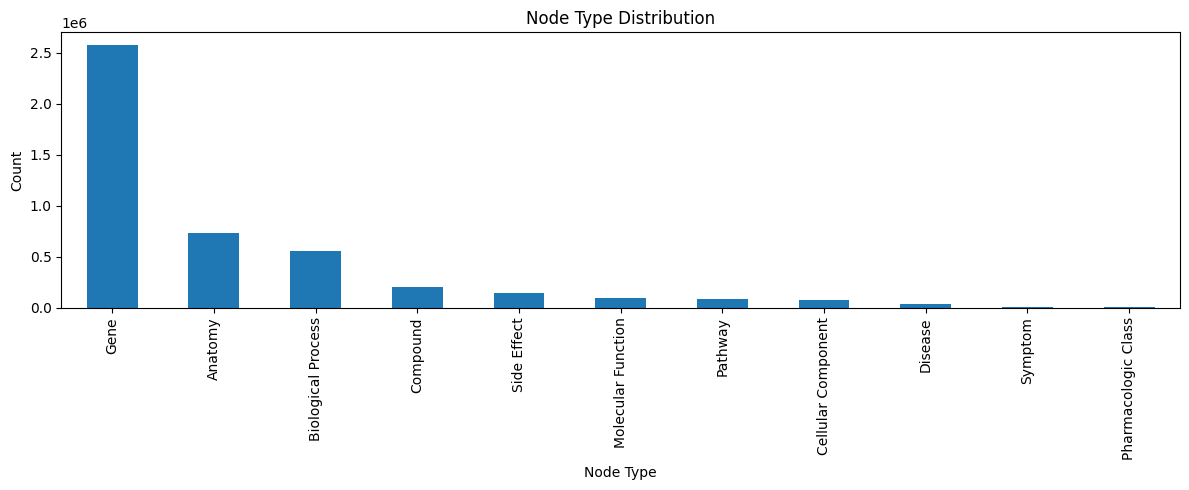

In [25]:
node_counts.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Node Type Distribution")

plt.xlabel("Node Type")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [26]:
pair_counts = (
    hetionet
    .groupby(["source_type","target_type"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

pair_counts.head(20)

,source_type,target_type,Count
0,Anatomy,Gene,726495
9,Gene,Biological Process,559504
11,Gene,Gene,474526
4,Compound,Side Effect,138944
12,Gene,Molecular Function,97222
13,Gene,Pathway,84372
10,Gene,Cellular Component,73566
3,Compound,Gene,51429
7,Disease,Gene,27977
1,Compound,Compound,6486


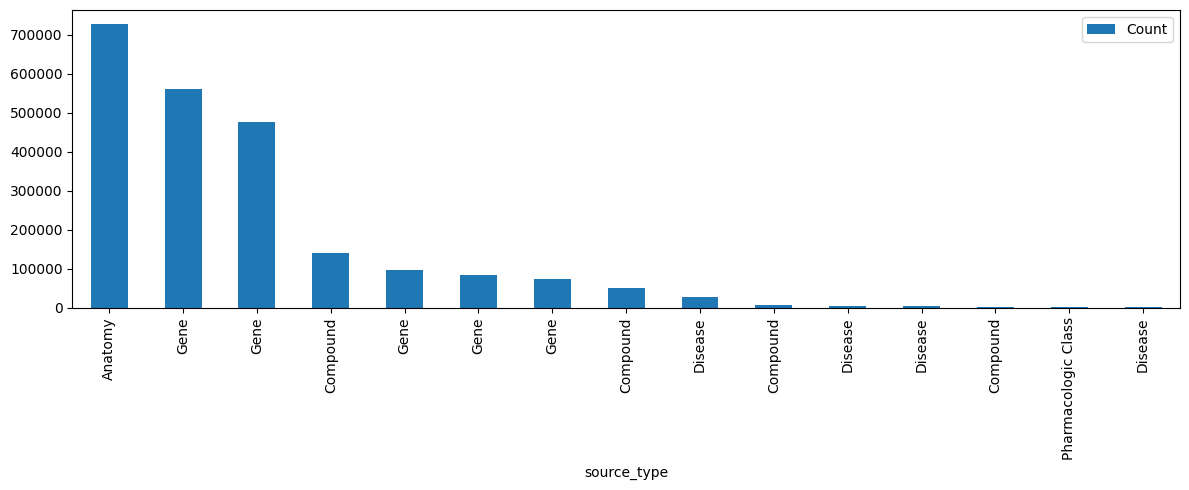

In [27]:
pair_counts.head(15).plot(
    x="source_type",
    y="Count",
    kind="bar",
    figsize=(12,5)
)

plt.tight_layout()

plt.show()

In [28]:
top_source = hetionet["source"].value_counts().head(20)

display(top_source)

source
Anatomy::UBERON:0000473    23866
Anatomy::UBERON:0000955    23606
Anatomy::UBERON:0002369    23115
Anatomy::UBERON:0000178    20779
Anatomy::UBERON:0000948    19693
Anatomy::UBERON:0002107    19428
Anatomy::UBERON:0002048    17955
Anatomy::UBERON:0002037    17284
Anatomy::UBERON:0002046    17095
Anatomy::UBERON:0000029    16874
Anatomy::UBERON:0001013    16715
Anatomy::UBERON:0000007    15961
Anatomy::UBERON:0002367    15553
Anatomy::UBERON:0000992    15533
Anatomy::UBERON:0002240    15045
Anatomy::UBERON:0001891    14891
Anatomy::UBERON:0001896    14552
Anatomy::UBERON:0000996    14259
Anatomy::UBERON:0000997    13481
Anatomy::UBERON:0001675    13266
Name: count, dtype: int64

In [29]:
top_target = hetionet["target"].value_counts().head(20)

display(top_target)

target
Gene::7316           2718
Pathway::PC7_7439    1956
Gene::6192           1871
Gene::991            1770
Gene::5111           1705
Pathway::PC7_5322    1564
Gene::57192          1399
Gene::4830           1285
Gene::10273          1260
Pathway::PC7_3278    1253
Gene::1465           1196
Gene::4118           1186
Gene::26520          1182
Gene::4282           1149
Pathway::PC7_4112    1142
Pathway::PC7_4688    1134
Gene::7298           1060
Pathway::PC7_7457    1013
Gene::22827          1009
Gene::9518           1004
Name: count, dtype: int64

# Neo4j Feasibility

Node Types
- Gene
- Disease
- Compound
- Anatomy
- Pathway
- Side Effect
- Symptom
- Biological Process

Relationship Types
- 24 Metaedge Types

Advantages
- Already graph structured
- Large biomedical network
- Rich relationships
- Excellent for Neo4j

Challenges
- Metaedge abbreviations need mapping
- Node labels need preprocessing

Overall Rating

⭐⭐⭐⭐⭐

Knowledge Graph Dashboard

Cards

- Total Nodes
- Total Edges
- Metaedge Distribution
- Node Type Distribution
- Top Connected Nodes
- Interactive Graph
- Search Node

Dataset Summary

Strengths

- Large biomedical graph
- Multiple node categories
- Multiple relationship types
- Ideal for Neo4j

Weaknesses

- Encoded node IDs
- Metaedge abbreviations

Recommendation

Excellent candidate for graph database implementation.

In [30]:
hetionet.head()

,source,metaedge,target,source_type,target_type
0,Gene::9021,GpBP,Biological Process::GO:0071357,Gene,Biological Process
1,Gene::51676,GpBP,Biological Process::GO:0098780,Gene,Biological Process
2,Gene::19,GpBP,Biological Process::GO:0055088,Gene,Biological Process
3,Gene::3176,GpBP,Biological Process::GO:0010243,Gene,Biological Process
4,Gene::3039,GpBP,Biological Process::GO:0006898,Gene,Biological Process


In [31]:
hetionet.columns

Index(['source', 'metaedge', 'target', 'source_type', 'target_type'], dtype='str')

In [32]:
hetionet["source"].head(20)

0      Gene::9021
1     Gene::51676
2        Gene::19
3      Gene::3176
4      Gene::3039
5      Gene::5962
6       Gene::841
7      Gene::6924
8      Gene::7407
9      Gene::9370
10      Gene::583
11     Gene::7101
12     Gene::8741
13     Gene::5714
14    Gene::84148
15    Gene::53371
16     Gene::2011
17     Gene::3670
18    Gene::10908
19     Gene::5684
Name: source, dtype: str

In [33]:
hetionet["target"].head(20)

0     Biological Process::GO:0071357
1     Biological Process::GO:0098780
2     Biological Process::GO:0055088
3     Biological Process::GO:0010243
4     Biological Process::GO:0006898
5     Biological Process::GO:0051346
6     Biological Process::GO:0043207
7     Biological Process::GO:0006354
8     Biological Process::GO:0006417
9     Biological Process::GO:0030852
10    Biological Process::GO:0008015
11    Biological Process::GO:0050768
12    Biological Process::GO:0002694
13    Biological Process::GO:0070201
14    Biological Process::GO:0010506
15    Biological Process::GO:0016925
16    Biological Process::GO:0010720
17    Biological Process::GO:0031056
18    Biological Process::GO:0006644
19    Biological Process::GO:0042770
Name: target, dtype: str

In [34]:
nodes = pd.concat([
    hetionet["source"],
    hetionet["target"]
]).drop_duplicates()

nodes = nodes.to_frame(name="full_id")

nodes.head()

,full_id
0,Gene::9021
1,Gene::51676
2,Gene::19
3,Gene::3176
4,Gene::3039


In [35]:
nodes["node_type"] = nodes["full_id"].str.split("::").str[0]

nodes["node_id"] = nodes["full_id"].str.split("::").str[1]

nodes.head()

,full_id,node_type,node_id
0,Gene::9021,Gene,9021
1,Gene::51676,Gene,51676
2,Gene::19,Gene,19
3,Gene::3176,Gene,3176
4,Gene::3039,Gene,3039


In [36]:
nodes["node_type"].value_counts()

node_type
Gene                   19145
Biological Process     11381
Side Effect             5701
Molecular Function      2884
Pathway                 1822
Compound                1538
Cellular Component      1391
Symptom                  415
Anatomy                  400
Pharmacologic Class      345
Disease                  136
Name: count, dtype: int64

In [37]:
import os

EXPORT_PATH = r"C:\Users\Ashal.Meeqaat\Desktop\Medical_KG_Project\Hetionet\csv"

os.makedirs(EXPORT_PATH, exist_ok=True)

for node_type in nodes["node_type"].unique():

    df = nodes[nodes["node_type"] == node_type][["node_id"]].copy()

    df.columns = ["id"]

    df["name"] = df["id"]

    filename = node_type.replace(" ", "_") + ".csv"

    df.to_csv(
        os.path.join(EXPORT_PATH, filename),
        index=False
    )

    print(filename, len(df))

Gene.csv 19145
Compound.csv 1538
Disease.csv 136
Anatomy.csv 400
Pharmacologic_Class.csv 345
Biological_Process.csv 11381
Symptom.csv 415
Molecular_Function.csv 2884
Cellular_Component.csv 1391
Pathway.csv 1822
Side_Effect.csv 5701


In [38]:
relationships = hetionet.copy()

relationships["source_type"] = relationships["source"].str.split("::").str[0]
relationships["source"] = relationships["source"].str.split("::").str[1]

relationships["target_type"] = relationships["target"].str.split("::").str[0]
relationships["target"] = relationships["target"].str.split("::").str[1]

relationships.rename(
    columns={"metaedge": "relation"},
    inplace=True
)

relationships.to_csv(
    r"C:\Users\Ashal.Meeqaat\Desktop\Medical_KG_Project\datasets\Processed\Hetionet\csv\Relationships.csv",
    index=False
)

relationships.head()

,source,relation,target,source_type,target_type
0,9021,GpBP,GO:0071357,Gene,Biological Process
1,51676,GpBP,GO:0098780,Gene,Biological Process
2,19,GpBP,GO:0055088,Gene,Biological Process
3,3176,GpBP,GO:0010243,Gene,Biological Process
4,3039,GpBP,GO:0006898,Gene,Biological Process


In [39]:
relationships.groupby(["source_type", "target_type"]).size().sort_values(ascending=False)

source_type          target_type       
Anatomy              Gene                  726495
Gene                 Biological Process    559504
                     Gene                  474526
Compound             Side Effect           138944
Gene                 Molecular Function     97222
                     Pathway                84372
                     Cellular Component     73566
Compound             Gene                   51429
Disease              Gene                   27977
Compound             Compound                6486
Disease              Anatomy                 3602
                     Symptom                 3357
Compound             Disease                 1145
Pharmacologic Class  Compound                1029
Disease              Disease                  543
dtype: int64

In [41]:
import os

output = r"C:\Users\Ashal.Meeqaat\Desktop\Medical_KG_Project\queries\Hetionet_queries\hetionet_relationships.cypher"

with open(output, "w", encoding="utf-8") as f:

    combos = relationships[["source_type","target_type"]].drop_duplicates()

    for _, row in combos.iterrows():

        s = row["source_type"]
        t = row["target_type"]

        slabel = f"`{s}`" if " " in s else s
        tlabel = f"`{t}`" if " " in t else t

        f.write(f"""
LOAD CSV WITH HEADERS FROM 'file:///Relationships.csv' AS row
WITH row
WHERE row.source_type='{s}' AND row.target_type='{t}'
MATCH (a:{slabel} {{id:row.source}})
MATCH (b:{tlabel} {{id:row.target}})
CREATE (a)-[:RELATED_TO {{type:row.relation}}]->(b);

""")

print("Done.")

Done.
